![alt text](img/MIoT_ML.png "MIoT_ML")

# Unidad 05 Desarrollo de modelos de redes neuronales

El objetivo de esta práctica es presentar las herramientas de desarrollo de Redes Neuronales Artificiales, en concreto la librería ```keras```, con ejemplo básicos de perceptrones y de redes convolucionales.

# Referencias de utilidad

1. [API scikit-learn](https://scikit-learn.org/stable/api/index.html)
2. [API matplotlib](https://matplotlib.org/stable/api/index.html)
3. [API keras](https://keras.io/api/)



## 1. Flujo de trabajo básico en problemas de Aprendizaje Automático (*ML workflow*)
A la hora de enfrentarnos a un nuevo problema de Aprendizaje Automático (ML), existen una serie de pasos típicos y comunes que debemos afrontar:
1. Entender el problema y su contexto.
2. Obtener los datos (histórico).
3. Explorar, analizar y entender los datos.
4. Preparar los datos para los modelos.
5. Seleccionar, optimizar y entrenar los modelos ML.
6. Evaluar y presentar el modelo seleccionado.
7. Desplegar, monitorizar y mantener la solución.

En esta unidad nos centraremos en los pasos 5 y 6 del flujo de trabajo, al igual que en la Unidad 4, pero con los nuevos modelos de Redes Neuronales Artificiales.

# 2. Librerías de programación

En esta unidad usaremos:

* `NumPy` → definiciones matemáticas y cómputos numéricos
* `TensorFlow` → cómputos tensoriales (RNAs)
* `Keras` → API de alto nivel para la definción de RNAs

## 2.1 Importar las librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except:
    !pip install tensorflow

# 3. Perceptrón

Un perceptrón implementa el siguiente cálculo:

$$
y = f_{act}(w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b)
$$

Donde:

* $w_1, w_2, \dots, w_n$ = pesos
* $b$ = bias
* $f_{act}$ = función de activación

Dependiendo de la función de activación:

* **Función paso** = perceptrón clásico
* **Función sigmoide** = verisón diferenciable (entrenable con descenso de gradiente)

## 3.1 Resolviendo el problema AND

El problema AND es aquel que tiene por objetivo modelar la función lógica

$$
\text{AND}: \{0,1\} \times \{0,1\} \rightarrow \{0,1\}
$$

de acuerdo a la tabla de verdad

| x1 | x2 | AND |
| -- | -- | --- |
| 0  | 0  | 0   |
| 0  | 1  | 0   |
| 1  | 0  | 0   |
| 1  | 1  | 1   |

Lo primero que haremos será definir el dataset correspondiente:

In [2]:
X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

Podemos visualizar los datos para comprobar que es un **problema linealmente separable**:

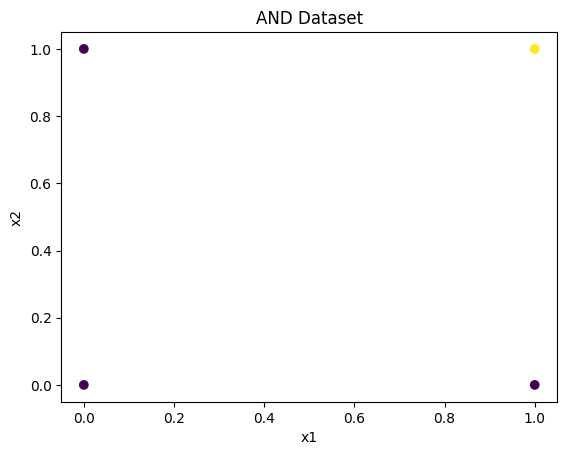

In [3]:
plt.scatter(X_and[:,0], X_and[:,1], c=y_and)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("AND Dataset")
plt.show()

Para definir el perceptrón que nos permita resolver el problema, definimos el siguiente **perceptrón**:

* Entrada: $[x_1, x_2]$
* Función activación: sigmoide $\sigma(z) = \frac{1}{1 - e^{-z}}$
* Salida: $y$

Para ello, utilizamos ```Keras``` de la siguiente forma:

In [4]:
model_and = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])

Una vez definido el modelo, debe **compilarse** con los parámetros de entrenamiento deseados, entre los que se encuentran:

* ```optimizer``` : algoritmo usado para minimizar la función de error
* ```loss```: función de pérdida, dependerá del problema en cuestión (https://keras.io/api/losses/)
* ```metrics```: métricas de referencia a la hora de entrenar

In [5]:
model_and.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Con el modelo compilado, procedemos a entrenarlo pasándole los datos del problema en cuestión:

In [6]:
model_and.fit(
    X_and, y_and,
    epochs=200,
    verbose=0
)

Una vez el modelo ha sido entrenado (i.e., se han establecido los pesos y el bias del perceptrón), podemos utilizarlo para **evaluar nuevos valores**, también llamado **predecir la salida**:

In [7]:
predictions = model_and.predict(X_and)
print("Predictions:")
print(np.round(predictions,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predictions:
[[0.457]
 [0.422]
 [0.25 ]
 [0.224]]


También es posible examinar los parámetros obtenidos. Para este problema es factible, ya que son pocos valores, pero normalmente no es un proceso que se haga manualmente.

In [8]:
weights, bias = model_and.layers[0].get_weights()
print("Weights:", weights)
print("Bias:", bias)

Weights: [[-0.9272169 ]
 [-0.14290789]]
Bias: [-0.17069295]


## 3.2 Resolviendo el problema OR

Prueba ahora a aplicar la misma metodología para resolver el problema OR, que tiene la siguiente tabla de verdad:

| x1 | x2 | OR |
| -- | -- | -- |
| 0  | 0  | 0  |
| 0  | 1  | 1  |
| 1  | 0  | 1  |
| 1  | 1  | 1  |

**EJERCICIO 1 - Para entregar en el aula virtual**

In [27]:
# 1. 定义 OR 问题的数据集
X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

# 2. 定义感知器模型
model_or = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])

# 3. 编译模型
model_or.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. 训练模型
model_or.fit(
    X_or, y_or,
    epochs=200,
    verbose=0  # 静默训练，不输出日志
)

# 5. 预测并打印结果
predictions_or = model_or.predict(X_or)
print("OR 问题预测结果（四舍五入到3位小数）：")
print(np.round(predictions_or, 3))

# 可选：打印模型权重和偏置
weights_or, bias_or = model_or.layers[0].get_weights()
print("\nOR 模型权重：", weights_or)
print("OR 模型偏置：", bias_or)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
OR 问题预测结果（四舍五入到3位小数）：
[[0.591]
 [0.399]
 [0.848]
 [0.72 ]]

OR 模型权重： [[ 1.3520836]
 [-0.7786045]]
OR 模型偏置： [0.36958596]


## 3.3 Resolviendo el problema XOR

Como vimos en clase, el problema XOR **no es linealmente separable**, por lo que el perceptrón por si sólo no podrá resolver el problema. Aún así, podemos plantearlo y desarrollarlo para ver qué sucede. Empezamos con la tabla de verdad:

| x1 | x2 | XOR |
| -- | -- | --- |
| 0  | 0  | 0   |
| 0  | 1  | 1   |
| 1  | 0  | 1   |
| 1  | 1  | 0   |

Probamos a visualizarlo:

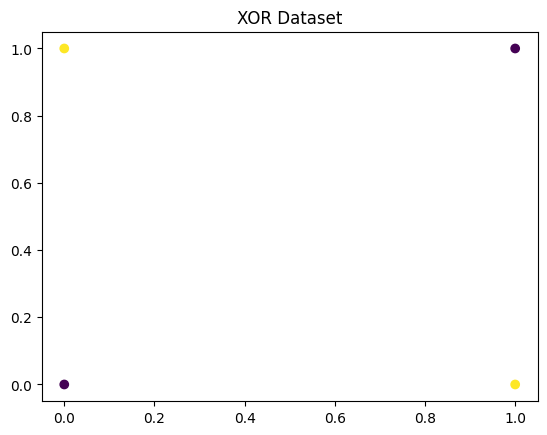

In [10]:
X_xor = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_xor = np.array([0,1,1,0])

plt.scatter(X_xor[:,0], X_xor[:,1], c=y_xor)
plt.title("XOR Dataset")
plt.show()

Relfexionemos un momento sobre este problema:
* ¿Podemos establecer una única línea recta que divida el conjunto de datos por clase?
* Teniendo esa respuesta en cuenta, ¿qué precisión debería presentar el modelo?

Probemos a solucionarlo mediante un perceptrón a ver qué sucede:

In [11]:
model_xor_single = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])

model_xor_single.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_xor_single.fit(X_xor, y_xor, epochs=500, verbose=0)

model_xor_single.evaluate(X_xor, y_xor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5000 - loss: 0.6957


[0.6956732273101807, 0.5]

¿Coincide la precisión obtenida con la que habías estimado? ¿Por qué obtenemos este resultado?

# 4. Perceptrón multicapa (MLP)

En clase vimos cómo para resolver problemas que no sean linealmente separables, se pueden agrupar múltiples perceptrones organizándolos en capas, obteniendo así un **perceptrón multicapa (MLP)**. Este nuevo modelo incluye **capas ocultas** que permiten modelar múltiples separadores lineales que resultan en un único **separador no-lineal**. Veamos cómo implementarlo con ```Keras```:

In [12]:
model_xor = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

Como todos los modelos que hemos creado hasta ahora son del tipo ```Keras.sequential```, podemos seguir aplicando la misma metodología de entrenamiento y predicción que hemos usado hasta ahora, aunque nuestro nuevo modelo sea más complejo:

In [13]:
model_xor.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_xor.fit(
    X_xor, y_xor,
    epochs=500,
)

model_xor.evaluate(X_xor, y_xor)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step - accuracy: 0.5000 - loss: 0.6892
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.6890
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5000 - loss: 0.6887
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.6885
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5000 - loss: 0.6883
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.6880
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5000 - loss: 0.6878
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5000 - loss: 0.6875
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5000 - loss: 0.6873
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.6871
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 0.6869
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - l

[0.5248842239379883, 0.5]

Y en este caso, podemos observar como el problema sí se resuelve con una precisión cercana al 100%.

# 5. *Deep Learning* (Aprendizaje Profundo)

Una vez comprendido el flujo de trabajo con RNAs, procedemos a ampliar el abanico de herramientas que tenemos a nuestra disposición. Para ello, vamos a implementar un modelo con Redes Neuronales Convolucionales (*Convolutional Neural Networks*, CNN) que clasifique imágenes de acuerdo a su contenido. En concreto, usaremos el dataset ```cifar-10``` que tenemos disponible en ```keras```.

Necesitaremos las siguientes librerías, además de las que ya importamos al principio del notebook:

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## 5.1 Descripción y carga de datos

El dataset ```cifar-10``` contiene 60 000 imágenes a color, con una resolución de 32x32 pixeles, con 3 canales de color (RGB). Contiene 10 clases de imágenes: ```"airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"```, con los datos distribuidos de forma balanceada entre todas ellas.

En primer lugar, cargamos en memoria los datos del dataset. Contamos con una función que nos permite hacerlo cómodamente, proporcionando conjuntos de entrenamiento y test:

In [15]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


Una vez tenemos los datos en memoria, podemos visualizar muestras de cada clase para comprender mejor cómo son:

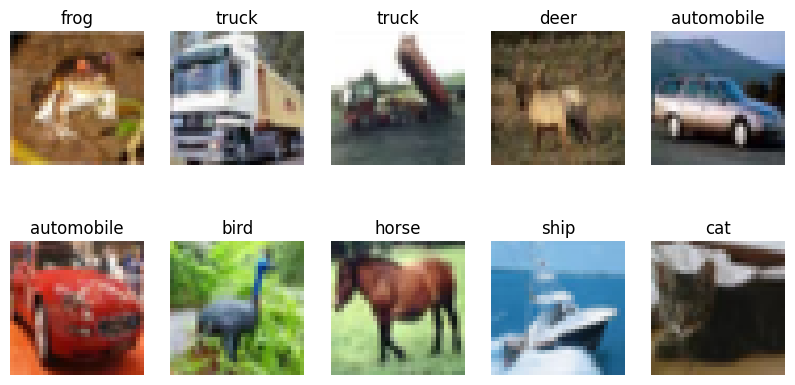

In [16]:
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.show()

## 5.2 Preprocesado de datos

Como hicimos en unidades anteriores, también es necesario preprocesar los datos para adaptarlos a la red que vamos a implementar. En este caso, lo primero que hacemos es **normalizar** las imágenes. Los valores de los pixeles están en el rango $(0,255)$, y conviene trasladarlos al rango $(0,1)$.

En cuanto a la salida, ahora mismo es por etiquetas (i.e., la salida son los nombres de las clases). Tenemos que convertirlo a otro tipo de dato que pueda devolver la red, por lo que utilizamos el método ```to_categorical``` para convertir cada etiqueta en un valor numérico del 1 al 10.

In [17]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

## 5.3 Primer modelo *naive*

Como primera aproximación, probamos a modelar una red como las que hemos usado hasta ahora, donde tenemos las neuronas por capas conectadas entre sí. A diferencia de las redes anteriores, en este caso tenemos que transformar ligeramente la entrada, para pasar las 32x32x3 entradas de cada imagen a la red. Para ello, incluimos la capa ```Flatten```.

In [18]:
baseline_model = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

El resto del proceso sigue siendo el mismo (compilación, entrenamiento, predicción), pero vamos a definir la siguiente función para poder visualizar el historial de entrenamiento:

In [19]:
def plot_history(history):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train', marker='o')
    plt.plot(history.history['val_accuracy'], label='val', marker='o')
    plt.title("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train', marker='o')
    plt.plot(history.history['val_loss'], label='val', marker='o')
    plt.title("Loss")
    plt.legend()

    plt.show()

Con esto, seguimos el proceso como siempre:

In [20]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.3175 - loss: 1.8980 - val_accuracy: 0.3595 - val_loss: 1.7766
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.3978 - loss: 1.6847 - val_accuracy: 0.4009 - val_loss: 1.6814
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.4267 - loss: 1.5967 - val_accuracy: 0.4374 - val_loss: 1.5901
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.4482 - loss: 1.5398 - val_accuracy: 0.4322 - val_loss: 1.6001
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.4639 - loss: 1.4987 - val_accuracy: 0.4470 - val_loss: 1.5622
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.4763 - loss: 1.4655 - val_accuracy: 0.4567 - val_loss: 1.5381
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4885 - loss: 1.4363 - val_accuracy: 0.4693 - val_loss: 1.5095
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.4988 - loss: 1.4006 - 

Una vez finalizado el entrenamiento, lo visualizamos:

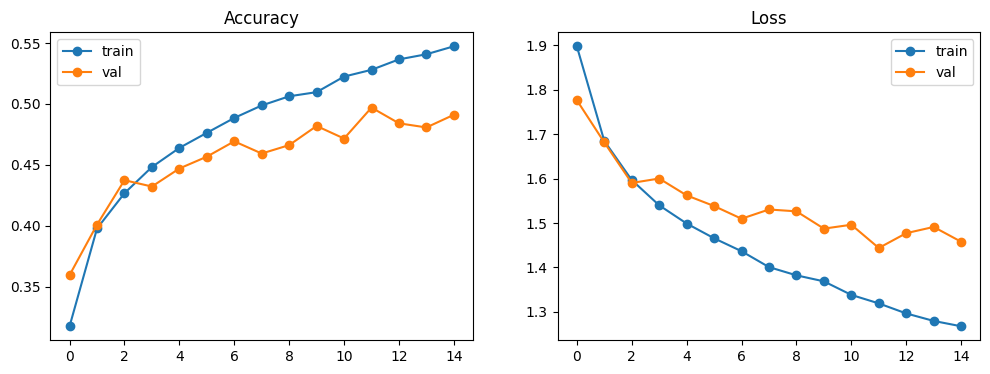

In [21]:
plot_history(history_baseline)

Según las gráficas, la precisión en el conjunto de validación es $\lt 50\%$, lo cual deja un gran margen de mejora. Teniendo en cuenta que los resultados de validación y entrenamiento divergen, un posible motivo para estos resultados es que el modelo esté haciendo ***overfitting***.

## 5.4 Regularización

Para solucionar problemas de *overfitting*, la solución es introducir en el modelo medidas de **regularización**. Como primera aproximación, vamos a intercalar capas de ```Dropout```, que desactivan conexiones de forma aleatoria, limitando el impacto de los datos de entrenamiento. Podemos añadir estas capas al modelo:

In [22]:
reg_model = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(10, activation='softmax')
])

Ahora, entrena este modelo para ver el impacto de las capas de ```Dropout```:

**EJERCICIO 2 - Para entregar en el aula virtual**

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2977 - loss: 1.9374 - val_accuracy: 0.3568 - val_loss: 1.7774
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.3585 - loss: 1.7726 - val_accuracy: 0.3978 - val_loss: 1.6940
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.3797 - loss: 1.7175 - val_accuracy: 0.4076 - val_loss: 1.6767
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.4043 - loss: 1.6614 - val_accuracy: 0.4255 - val_loss: 1.6036
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.4171 - loss: 1.6328 - val_accuracy: 0.4404 - val_loss: 1.5826
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.4229 - loss: 1.6053 - val_accuracy: 0.4312 - val_loss: 1.5860
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.4315 - loss: 1.5827 - val_accuracy: 0.4437 - val_loss: 1.5634
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.4397 - loss: 1.5637 - 

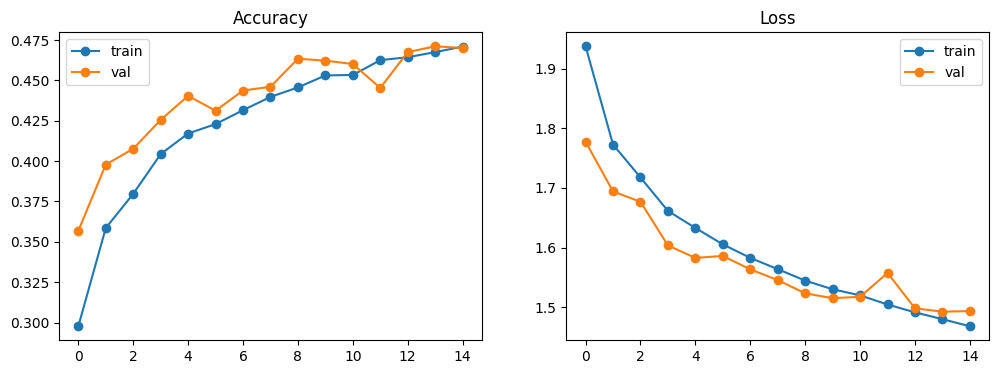

In [28]:
# 1. 编译正则化模型
reg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. 训练模型
history_reg = reg_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

# 3. 可视化训练历史
plot_history(history_reg)

**Escribe aquí abajo los comentarios**



## 5.5 Redes Neuronales Convolucionales (CNNs)

Una característica clave de las imágenes es la **correlación espacial** de los datos. No aporta la misma información dos pixeles contiguos del mismo color, que dos pixeles separados con el mismo color (entre otros muchos ejemplos). Por lo tanto, vamos a implementar una red que tenga en cuenta estas correlaciones, una **Red Neuronal Convolucional (*Convulutional Neural Netowrk*, CNN)**. Estas redes disponen sus neuronas de forma que aplican operaciones de **convolución** sobre los datos que reciben:

![./img/cnn-convolution.jpg](https://github.com/dmerap/MIOT_ML/blob/main/img/cnn-convolution.jpg?raw=1)

También se realizan operaciones de reuducción de la dimensionalidad, con el objetivo de reducir los datos a caracterísitcas que puedan ser clasificados. Entre estas operaciones se encuentra **max pooling**, que selecciona el máximo valor del rango indicado:

![./img/cnn-pooling.png](https://github.com/dmerap/MIOT_ML/blob/main/img/cnn-pooling.png?raw=1)

In [24]:
cnn_model = keras.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

Debido a la complejidad del modelo, puede ser útil visualizar de forma rápida las capas y parámetros que lo componen. Esta información está disponible a través del método ```summary()```:

In [25]:
cnn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,458 (1.07 MB)

 Trainable params: 280,458 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

De nuevo, compilamos y entrenamos el modelo:

In [29]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 217s 344ms/step - accuracy: 0.5324 - loss: 1.2931 - val_accuracy: 0.6163 - val_loss: 1.0974
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 249s 324ms/step - accuracy: 0.5888 - loss: 1.1518 - val_accuracy: 0.6644 - val_loss: 0.9522
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 263s 326ms/step - accuracy: 0.6381 - loss: 1.0332 - val_accuracy: 0.6963 - val_loss: 0.8698
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 262s 325ms/step - accuracy: 0.6666 - loss: 0.9395 - val_accuracy: 0.7171 - val_loss: 0.8118
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 213s 340ms/step - accuracy: 0.6974 - loss: 0.8615 - val_accuracy: 0.7282 - val_loss: 0.7820
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 204s 326ms/step - accuracy: 0.7218 - loss: 0.7929 - val_accuracy: 0.7329 - val_loss: 0.7690
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 322ms/step - accuracy: 0.7409 - loss: 0.7428 - val_accuracy: 0.7512 - val_loss: 0.7453
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 328ms/step - accuracy: 0.7593 -

Ahora obtenemos mejores resultados gracias al cambio de arquitectura:

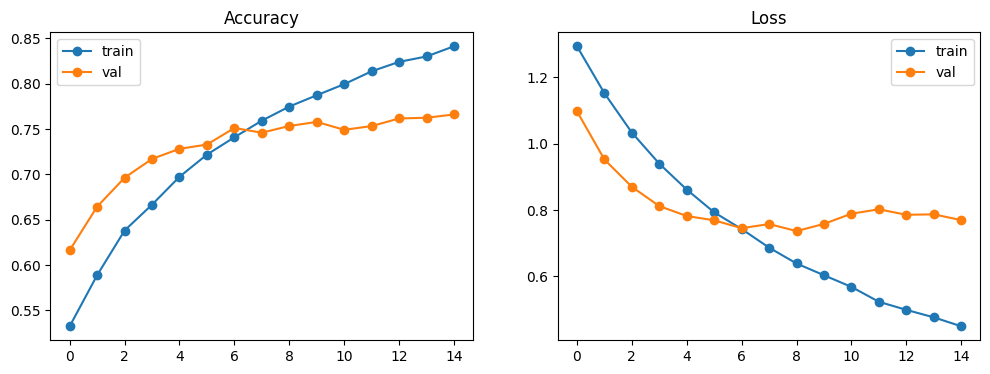

In [30]:
plot_history(history_cnn)

Dado que este problema (```cifar-10```) es de mayor complejidad que los vistos previamente, es de interés tener alguna forma de visualizar claramente el rendimiento del modelo con los datos de test. Podemos hacer un simple cálculo de la precisión:

In [31]:
test_loss, test_acc = cnn_model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.7627 - loss: 0.7936
Test accuracy: 0.7627000212669373


O podemos visualizar la **matriz de confusión**, que permite comprender de un vistazo qué tal clasifica la red, así como cuáles son las clases que más se "confunden" con otras:

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step


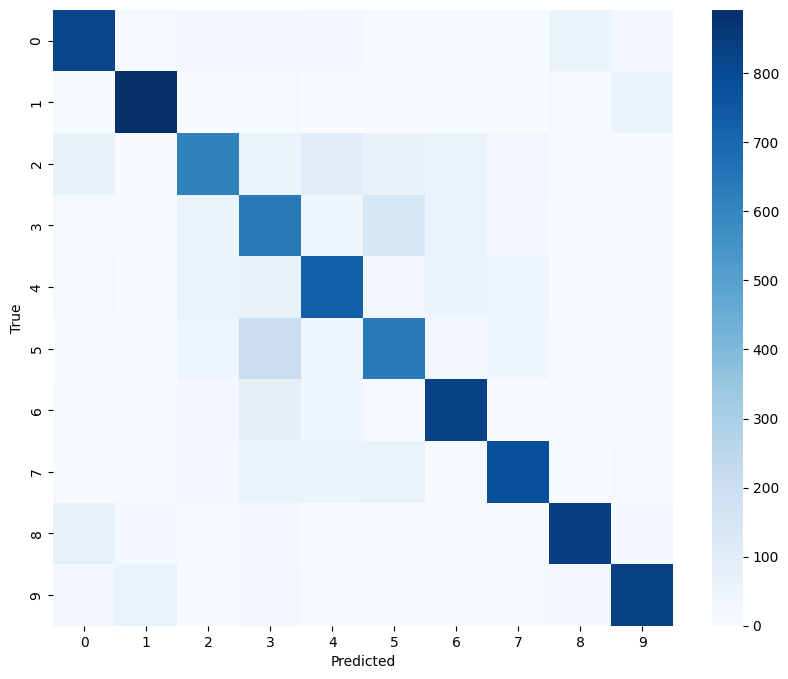

In [32]:
y_pred = cnn_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 6 Modelo final y conclusiones

Como último ejercicio de esta unidad, **desarrolla un nuevo modelo** utilizando las herramientas que hemos visto (capas, regularización, hiperparámetros) y al menos una a mayores de entre:

* Data agumentation: https://keras.io/api/layers/preprocessing_layers/image_augmentation/
* Batch normalization: https://keras.io/api/layers/normalization_layers/batch_normalization/
* Optimizers: https://keras.io/api/optimizers/

Anota los resultados de los anteriores modelos y del nuevo en la tabla a continuación, y comenta brevemente a qué se deben.

**EJERCICIO 3 - Para entregar en el aula virutal**

| Modelo      | Train Acc | Val Acc | Overfitting? |
| ----------- | --------- | ------- | ------------ |
| Naive       |           |         |              |
| Naive + Reg |           |         |              |
| CNN         |           |         |              |
| CNN Propia  |           |         |              |

**Comentario**:

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 302ms/step - accuracy: 0.3673 - loss: 1.8520 - val_accuracy: 0.4528 - val_loss: 1.5253 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 302ms/step - accuracy: 0.5126 - loss: 1.3584 - val_accuracy: 0.5674 - val_loss: 1.2096 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 188s 301ms/step - accuracy: 0.5818 - loss: 1.1728 - val_accuracy: 0.5877 - val_loss: 1.1912 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 204s 305ms/step - accuracy: 0.6248 - loss: 1.0653 - val_accuracy: 0.6102 - val_loss: 1.0882 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 310ms/step - accuracy: 0.6478 - loss: 1.0065 - val_accuracy: 0.6956 - val_loss: 0.8772 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 187s 300ms/step - accuracy: 0.6662 - loss: 0.9452 - val_accuracy: 0.6606 - val_loss: 0.9650 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 186s 298ms/step - accura

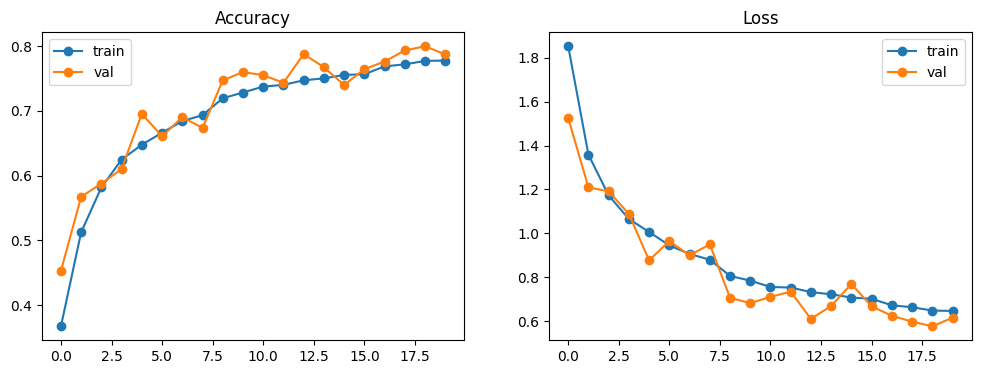

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.7810 - loss: 0.6423
Precisión en test del CNN mejorado： 0.781000018119812


In [35]:
# Preprocesamiento de datos (reutilizado)
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Paso 1: Definir la capa de aumento de datos (resuelve sobreajuste + amplía datos)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomZoom(0.1),
])

# Paso 2: Definir el modelo CNN mejorado (con BatchNorm + ajuste de optimizador)
improved_cnn = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    # Aumento de datos (solo activo en fase de entrenamiento)
    data_augmentation,
    # Bloque convolucional 1 + BatchNorm
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),
    # Bloque convolucional 2 + BatchNorm
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),
    # Bloque convolucional 3 + BatchNorm
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),
    # Cabeza de clasificación
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilar (usando optimizador AdamW con decaimiento de pesos)
improved_cnn.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar el modelo (con decaimiento de tasa de aprendizaje)
history_improved = improved_cnn.fit(
    x_train, y_train,
    epochs=20,  # Aumentar epochs (el aumento de datos requiere más iteraciones)
    batch_size=64,
    validation_split=0.2,
    callbacks=[keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)]
)

# Visualizar el historial de entrenamiento
plot_history(history_improved)

# Evaluar en el conjunto de test
test_loss_improved, test_acc_improved = improved_cnn.evaluate(x_test, y_test)
print("Precisión en test del CNN mejorado：", test_acc_improved)